# 🏠 Household Energy Consumption Forecasting

This notebook builds and compares two deep learning models — **MLP (Multi-Layer Perceptron)** and **LSTM (Long Short-Term Memory)** — for forecasting household power consumption using the [UCI Household Power Consumption Dataset](https://www.kaggle.com/datasets/uciml/electric-power-consumption-data-set).

---
### 📌 Project Overview
- **Dataset**: Minute-level household electricity measurements (2006–2010)
- **Target Variable**: `Global_active_power` (kW)
- **Models**: MLP vs LSTM
- **Metrics**: RMSE, MAE, R² Score

In [1]:
# Import Requirements
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# For reproducible results
np.random.seed(42)
tf.random.set_seed(42)

print('Libraries loaded successfully!')

Libraries loaded successfully!


In [2]:
# Load data
data = pd.read_csv('/household_power_consumption 2.txt',
                   sep=';',
                   parse_dates={'datetime': ['Date', 'Time']},
                   infer_datetime_format=True,
                   na_values=['?'])

print('Dataset shape:', data.shape)
print('\nFirst few rows:')
print(data.head())
print('\nMissing values:')
print(data.isnull().sum())

/tmp/ipykernel_2917/1428702550.py:2: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  data = pd.read_csv('/household_power_consumption 2.txt',
/tmp/ipykernel_2917/1428702550.py:2: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  data = pd.read_csv('/household_power_consumption 2.txt',


Dataset shape: (2075259, 8)

First few rows:
             datetime  Global_active_power  Global_reactive_power  Voltage  \
0 2006-12-16 17:24:00                4.216                  0.418   234.84   
1 2006-12-16 17:25:00                5.360                  0.436   233.63   
2 2006-12-16 17:26:00                5.374                  0.498   233.29   
3 2006-12-16 17:27:00                5.388                  0.502   233.74   
4 2006-12-16 17:28:00                3.666                  0.528   235.68   

   Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  
0              18.4             0.0             1.0            17.0  
1              23.0             0.0             1.0            16.0  
2              23.0             0.0             2.0            17.0  
3              23.0             0.0             1.0            17.0  
4              15.8             0.0             1.0            17.0  

Missing values:
datetime                     0
Global_active_powe

/tmp/ipykernel_2917/1428702550.py:2: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data = pd.read_csv('/household_power_consumption 2.txt',


In [3]:
# Remove rows with missing values
data = data.dropna()
data = data.reset_index(drop=True)

# Convert target to float
data['Global_active_power'] = data['Global_active_power'].astype(float)

print('After cleaning:', data.shape)
print('Date range:', data['datetime'].min(), 'to', data['datetime'].max())

After cleaning: (2049280, 8)
Date range: 2006-12-16 17:24:00 to 2010-11-26 21:02:00


## Exploratory Data Analysis (EDA)

In [4]:
data.describe()

,datetime,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,2049280,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06
mean,2008-12-02 00:59:44.397740544,1.091615e+00,1.237145e-01,2.408399e+02,4.627759e+00,1.121923e+00,1.298520e+00,6.458447e+00
min,2006-12-16 17:24:00,7.600000e-02,0.000000e+00,2.232000e+02,2.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00
25%,2007-12-10 05:37:45,3.080000e-01,4.800000e-02,2.389900e+02,1.400000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2008-11-30 01:22:30,6.020000e-01,1.000000e-01,2.410100e+02,2.600000e+00,0.000000e+00,0.000000e+00,1.000000e+00
75%,2009-11-23 20:31:15,1.528000e+00,1.940000e-01,2.428900e+02,6.400000e+00,0.000000e+00,1.000000e+00,1.700000e+01
max,2010-11-26 21:02:00,1.112200e+01,1.390000e+00,2.541500e+02,4.840000e+01,8.800000e+01,8.000000e+01,3.100000e+01
std,NaN,1.057294e+00,1.127220e-01,3.239987e+00,4.444396e+00,6.153031e+00,5.822026e+00,8.437154e+00


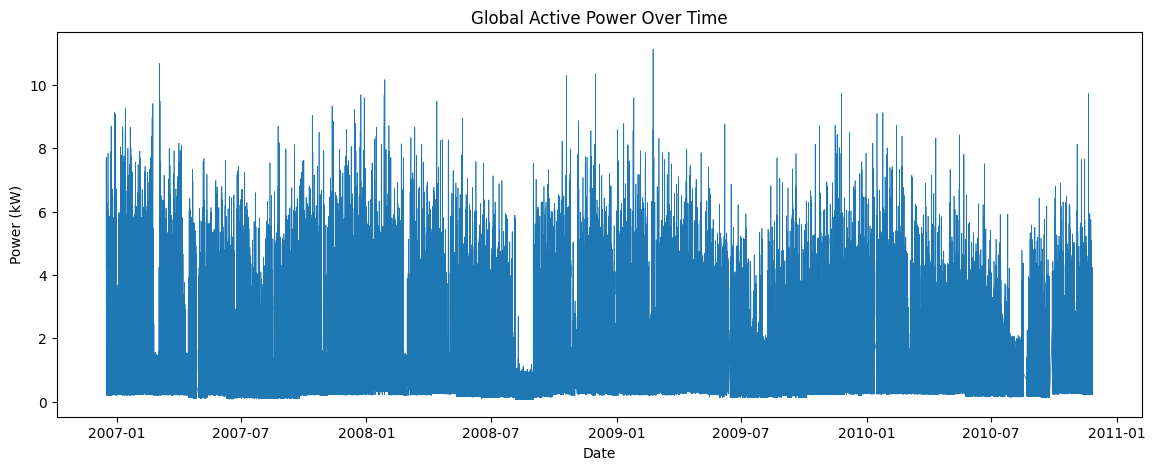

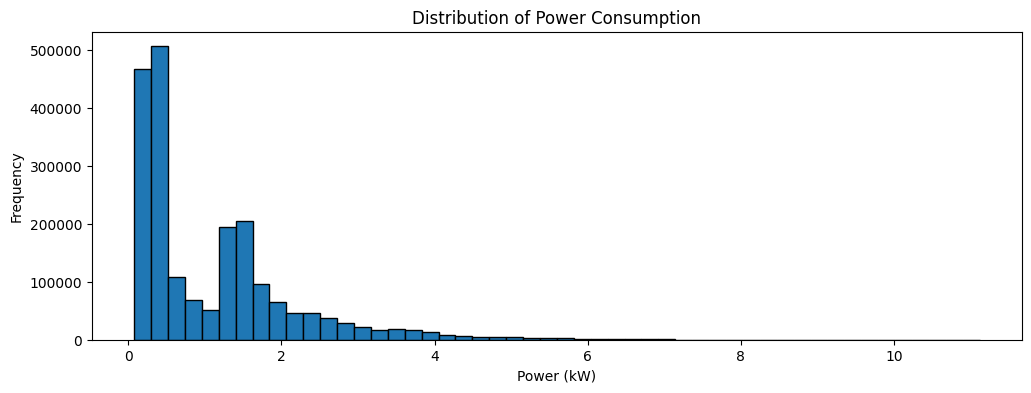

In [5]:
# Plot full time series
plt.figure(figsize=(14, 5))
plt.plot(data['datetime'], data['Global_active_power'], linewidth=0.5)
plt.title('Global Active Power Over Time')
plt.xlabel('Date')
plt.ylabel('Power (kW)')
plt.show()

# Distribution
plt.figure(figsize=(12, 4))
plt.hist(data['Global_active_power'], bins=50, edgecolor='black')
plt.title('Distribution of Power Consumption')
plt.xlabel('Power (kW)')
plt.ylabel('Frequency')
plt.show()

## Sampling & Feature Engineering

Sample size: (1000000, 8)


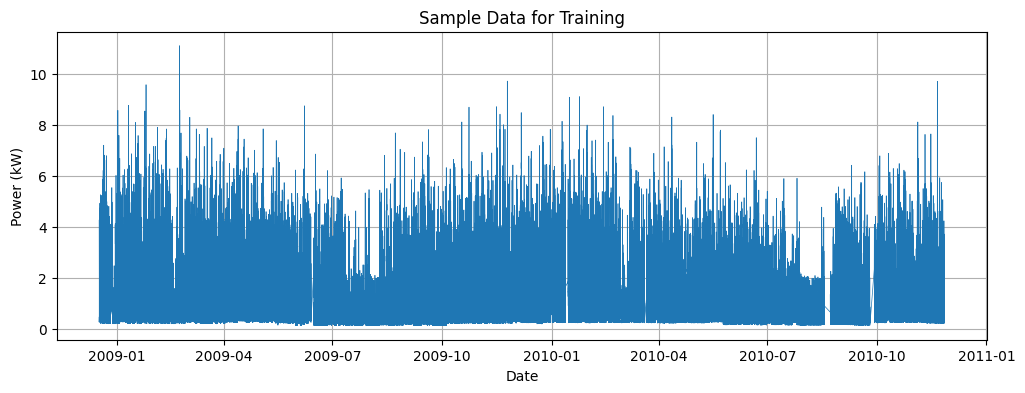

In [6]:
# Use last 10,00,000 records for faster training
sample_data = data.tail(1000000).reset_index(drop=True)
print('Sample size:', sample_data.shape)

# Visualize sample
plt.figure(figsize=(12, 4))
plt.plot(sample_data['datetime'], sample_data['Global_active_power'], linewidth=0.5)
plt.title('Sample Data for Training')
plt.xlabel('Date')
plt.ylabel('Power (kW)')
plt.grid()
plt.show()

In [7]:
# Select features for model
features = ['Global_active_power', 'Global_reactive_power', 'Voltage',
            'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

# Get feature values
values = sample_data[features].values
print('Features shape:', values.shape)
print('Features used:', features)

Features shape: (1000000, 7)
Features used: ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']


## Preprocessing — Normalization & Sequence Creation

In [8]:
# Normalize to 0-1 range
scaler = MinMaxScaler()
scaled_values = scaler.fit_transform(values)

print('Data normalized')
print('Min:', scaled_values.min())
print('Max:', scaled_values.max())

Data normalized
Min: 0.0
Max: 1.0


In [9]:
# Function to create sequences
def create_sequences(data, lookback=60):
    X = []
    y = []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i])
        y.append(data[i, 0])  # Predict first column (Global_active_power)
    return np.array(X), np.array(y)

# Create sequences with 60 time steps (1 hour lookback)
lookback = 60
X, y = create_sequences(scaled_values, lookback)

print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (999940, 60, 7)
y shape: (999940,)


In [10]:
# 80-20 split
split = int(0.8 * len(X))

X_train = X[:split]
y_train = y[:split]
X_test  = X[split:]
y_test  = y[split:]

print('Training samples:', X_train.shape[0])
print('Testing samples:', X_test.shape[0])

Training samples: 799952
Testing samples: 199988


# Model 1 — MLP (Multi-Layer Perceptron)

In [11]:
# MLP needs flattened input
from tensorflow.keras.layers import Flatten

mlp_model = Sequential([
    Flatten(input_shape=(lookback, len(features))),  # Flatten 3D to 2D
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

mlp_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
mlp_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 420)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        53,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,257 (251.00 KB)

 Trainable params: 64,257 (251.00 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# No need to reshape - use original X_train directly
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train model with 3D input (Flatten layer handles it)
history_mlp = mlp_model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.15,
    callbacks=[early_stop],
    verbose=1
)

print('\nMLP training completed!')

Epoch 1/30
21249/21249 ━━━━━━━━━━━━━━━━━━━━ 88s 4ms/step - loss: 8.3663e-04 - mae: 0.0157 - val_loss: 0.0010 - val_mae: 0.0180
Epoch 2/30
21249/21249 ━━━━━━━━━━━━━━━━━━━━ 67s 3ms/step - loss: 6.1045e-04 - mae: 0.0125 - val_loss: 0.0011 - val_mae: 0.0192
Epoch 3/30
21249/21249 ━━━━━━━━━━━━━━━━━━━━ 65s 3ms/step - loss: 5.8086e-04 - mae: 0.0119 - val_loss: 0.0010 - val_mae: 0.0188
Epoch 4/30
21249/21249 ━━━━━━━━━━━━━━━━━━━━ 65s 3ms/step - loss: 5.6320e-04 - mae: 0.0116 - val_loss: 0.0010 - val_mae: 0.0193
Epoch 5/30
21249/21249 ━━━━━━━━━━━━━━━━━━━━ 64s 3ms/step - loss: 5.5427e-04 - mae: 0.0114 - val_loss: 0.0010 - val_mae: 0.0194
Epoch 6/30
21249/21249 ━━━━━━━━━━━━━━━━━━━━ 64s 3ms/step - loss: 5.5103e-04 - mae: 0.0113 - val_loss: 0.0010 - val_mae: 0.0200
Epoch 7/30
21249/21249 ━━━━━━━━━━━━━━━━━━━━ 65s 3ms/step - loss: 5.4854e-04 - mae: 0.0112 - val_loss: 9.8781e-04 - val_mae: 0.0186
Epoch 8/30
21249/21249 ━━━━━━━━━━━━━━━━━━━━ 63s 3ms/step - loss: 5.4184e-04 - mae: 0.0111 - val_loss: 9.051

# Model 2 — LSTM (Long Short-Term Memory)

In [13]:
# LSTM architecture
lstm_model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(lookback, len(features))),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 128)        │        69,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,153 (473.25 KB)

 Trainable params: 121,153 (473.25 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Train LSTM
history_lstm = lstm_model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.15,
    callbacks=[early_stop],
    verbose=1
)

print('\nLSTM training completed!')

Epoch 1/30
21249/21249 ━━━━━━━━━━━━━━━━━━━━ 234s 11ms/step - loss: 6.1500e-04 - mae: 0.0124 - val_loss: 4.4414e-04 - val_mae: 0.0101
Epoch 2/30
21249/21249 ━━━━━━━━━━━━━━━━━━━━ 228s 11ms/step - loss: 5.1652e-04 - mae: 0.0108 - val_loss: 4.4137e-04 - val_mae: 0.0103
Epoch 3/30
21249/21249 ━━━━━━━━━━━━━━━━━━━━ 227s 11ms/step - loss: 4.8832e-04 - mae: 0.0103 - val_loss: 4.0914e-04 - val_mae: 0.0092
Epoch 4/30
21249/21249 ━━━━━━━━━━━━━━━━━━━━ 229s 11ms/step - loss: 4.7179e-04 - mae: 0.0100 - val_loss: 4.0477e-04 - val_mae: 0.0093
Epoch 5/30
21249/21249 ━━━━━━━━━━━━━━━━━━━━ 259s 11ms/step - loss: 4.5813e-04 - mae: 0.0097 - val_loss: 3.9199e-04 - val_mae: 0.0089
Epoch 6/30
21249/21249 ━━━━━━━━━━━━━━━━━━━━ 225s 11ms/step - loss: 4.4636e-04 - mae: 0.0095 - val_loss: 3.8474e-04 - val_mae: 0.0087
Epoch 7/30
21249/21249 ━━━━━━━━━━━━━━━━━━━━ 230s 11ms/step - loss: 4.3679e-04 - mae: 0.0094 - val_loss: 3.8112e-04 - val_mae: 0.0090
Epoch 8/30
21249/21249 ━━━━━━━━━━━━━━━━━━━━ 231s 11ms/step - loss: 4.

## Training History Comparison

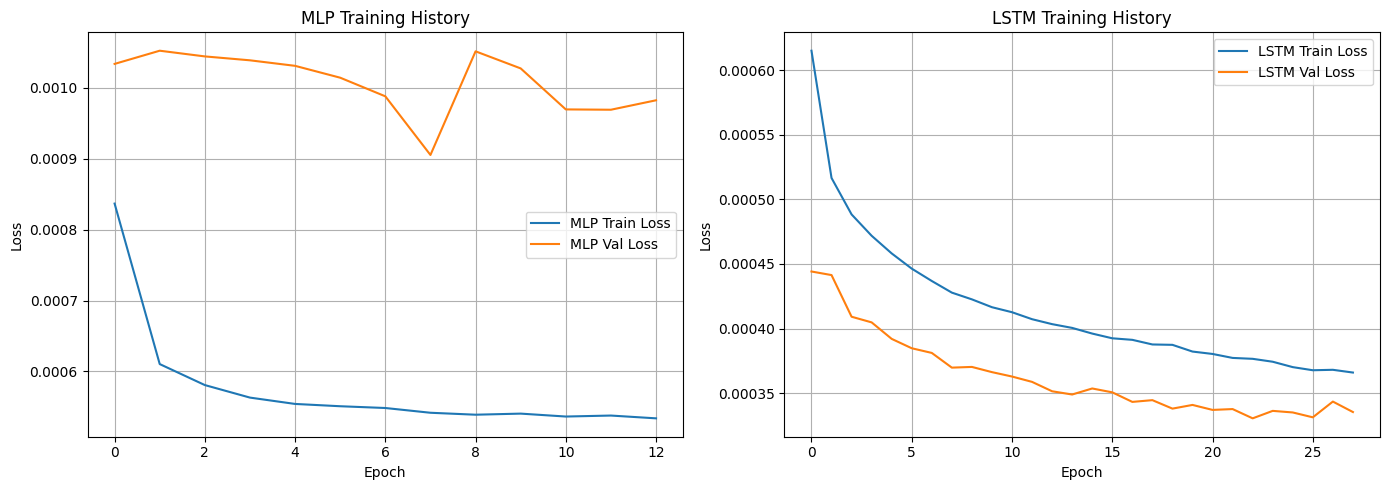

In [15]:
# Compare training curves
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_mlp.history['loss'], label='MLP Train Loss')
plt.plot(history_mlp.history['val_loss'], label='MLP Val Loss')
plt.title('MLP Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_lstm.history['loss'], label='LSTM Train Loss')
plt.plot(history_lstm.history['val_loss'], label='LSTM Val Loss')
plt.title('LSTM Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Predictions & Evaluation

In [16]:
# Get predictions - both models use X_test (3D shape)
mlp_pred  = mlp_model.predict(X_test, verbose=0)
lstm_pred = lstm_model.predict(X_test, verbose=0)

print('Predictions generated')
print('MLP predictions shape:', mlp_pred.shape)
print('LSTM predictions shape:', lstm_pred.shape)

Predictions generated
MLP predictions shape: (199988, 1)
LSTM predictions shape: (199988, 1)


In [ ]:
# Inverse transform to get actual power values
def inverse_transform_target(predictions, scaler, n_features):
    dummy = np.zeros((len(predictions), n_features))
    dummy[:, 0] = predictions.flatten()
    return scaler.inverse_transform(dummy)[:, 0]

# Convert back to kW
y_test_actual    = inverse_transform_target(y_test, scaler, len(features))
mlp_pred_actual  = inverse_transform_target(mlp_pred, scaler, len(features))
lstm_pred_actual = inverse_transform_target(lstm_pred, scaler, len(features))

print('Values converted to original scale')

In [ ]:
# Calculate performance metrics
def evaluate_model(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)

    print(f'\n{model_name} Results:')
    print(f'RMSE: {rmse:.4f} kW')
    print(f'MAE:  {mae:.4f} kW')
    print(f'R² Score: {r2:.4f}')

    return rmse, mae, r2

mlp_rmse,  mlp_mae,  mlp_r2  = evaluate_model(y_test_actual, mlp_pred_actual,  'MLP')
lstm_rmse, lstm_mae, lstm_r2 = evaluate_model(y_test_actual, lstm_pred_actual, 'LSTM')

# Visualizations — Model Comparison

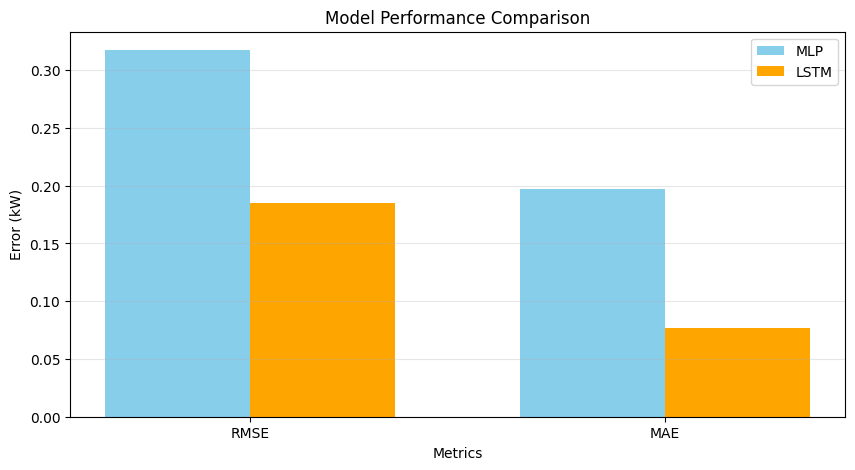

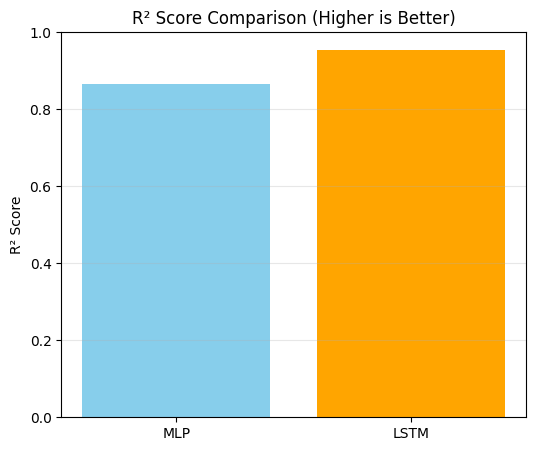

In [20]:
# Bar chart comparing models
metrics    = ['RMSE', 'MAE']
mlp_scores  = [mlp_rmse, mlp_mae]
lstm_scores = [lstm_rmse, lstm_mae]

x     = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, mlp_scores,  width, label='MLP',  color='skyblue')
plt.bar(x + width/2, lstm_scores, width, label='LSTM', color='orange')
plt.xlabel('Metrics')
plt.ylabel('Error (kW)')
plt.title('Model Performance Comparison')
plt.xticks(x, metrics)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# R² comparison
plt.figure(figsize=(6, 5))
plt.bar(['MLP', 'LSTM'], [mlp_r2, lstm_r2], color=['skyblue', 'orange'])
plt.ylabel('R² Score')
plt.title('R² Score Comparison (Higher is Better)')
plt.ylim([0, 1])
plt.grid(axis='y', alpha=0.3)
plt.show()

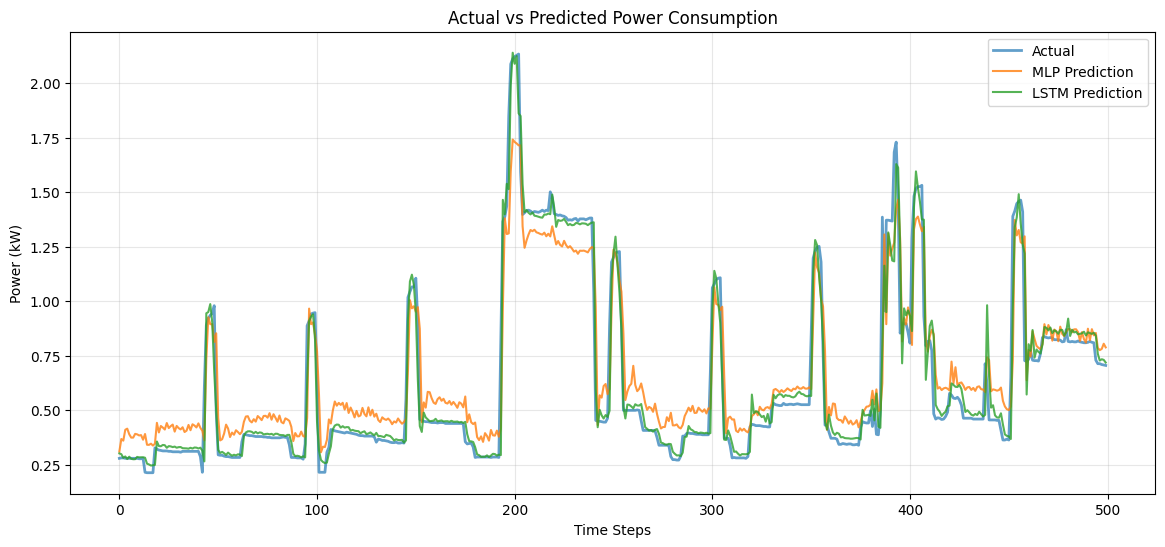

In [21]:
# Plot first 500 predictions
n_samples = 500

plt.figure(figsize=(14, 6))
plt.plot(y_test_actual[:n_samples],    label='Actual',          linewidth=2,   alpha=0.7)
plt.plot(mlp_pred_actual[:n_samples],  label='MLP Prediction',  linewidth=1.5, alpha=0.8)
plt.plot(lstm_pred_actual[:n_samples], label='LSTM Prediction', linewidth=1.5, alpha=0.8)
plt.title('Actual vs Predicted Power Consumption')
plt.xlabel('Time Steps')
plt.ylabel('Power (kW)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

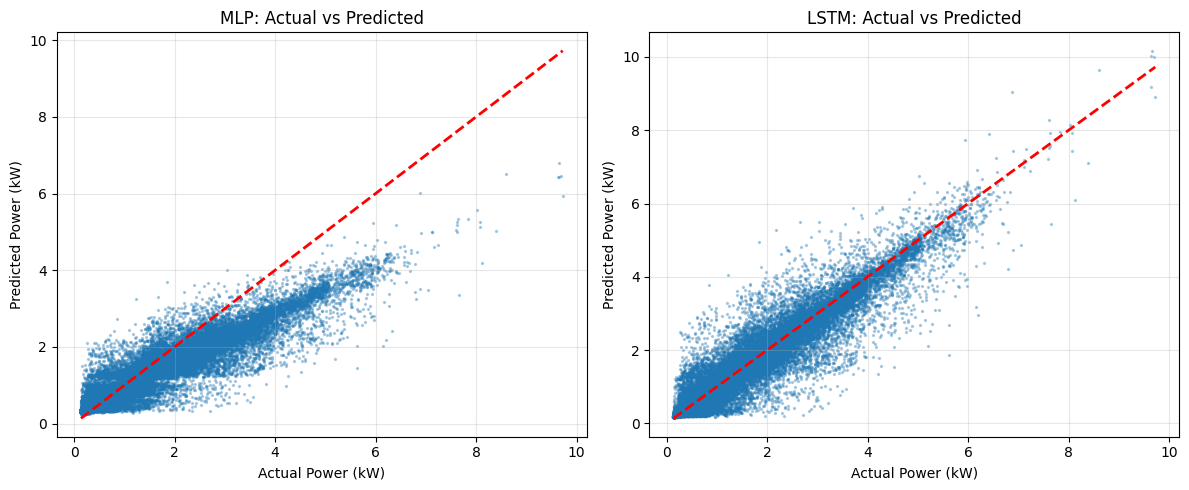

In [22]:
# Actual vs Predicted scatter plots
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test_actual, mlp_pred_actual, alpha=0.3, s=2)
plt.plot([y_test_actual.min(), y_test_actual.max()],
         [y_test_actual.min(), y_test_actual.max()], 'r--', linewidth=2)
plt.xlabel('Actual Power (kW)')
plt.ylabel('Predicted Power (kW)')
plt.title('MLP: Actual vs Predicted')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(y_test_actual, lstm_pred_actual, alpha=0.3, s=2)
plt.plot([y_test_actual.min(), y_test_actual.max()],
         [y_test_actual.min(), y_test_actual.max()], 'r--', linewidth=2)
plt.xlabel('Actual Power (kW)')
plt.ylabel('Predicted Power (kW)')
plt.title('LSTM: Actual vs Predicted')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

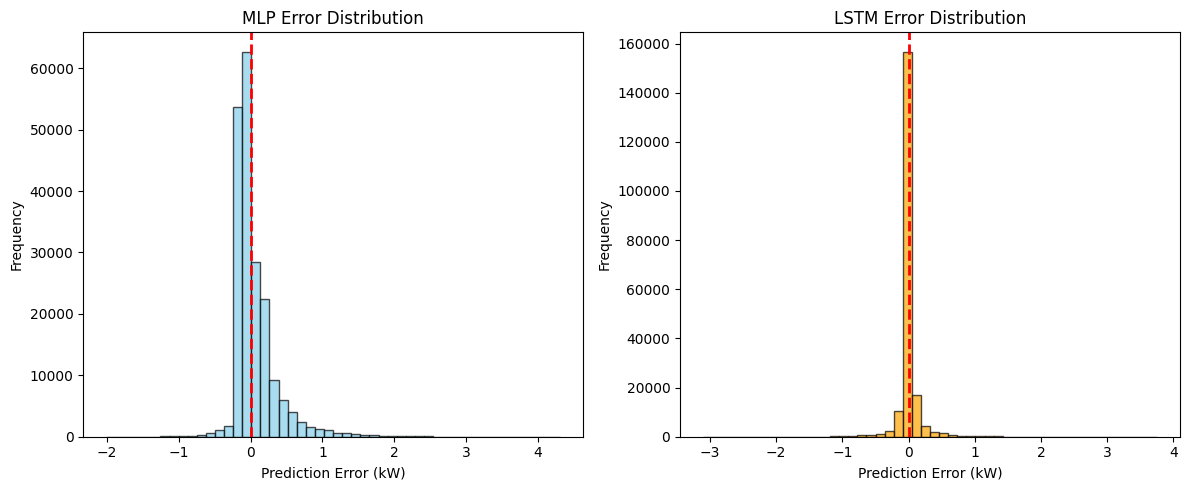

In [23]:
# Calculate errors
mlp_errors  = y_test_actual - mlp_pred_actual
lstm_errors = y_test_actual - lstm_pred_actual

# Error distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(mlp_errors, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Prediction Error (kW)')
plt.ylabel('Frequency')
plt.title('MLP Error Distribution')

plt.subplot(1, 2, 2)
plt.hist(lstm_errors, bins=50, color='orange', edgecolor='black', alpha=0.7)
plt.axvline(0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Prediction Error (kW)')
plt.ylabel('Frequency')
plt.title('LSTM Error Distribution')

plt.tight_layout()
plt.show()

# Final Results Summary

In [24]:
# Create summary table
summary = pd.DataFrame({
    'Model':    ['MLP', 'LSTM'],
    'RMSE (kW)': [mlp_rmse, lstm_rmse],
    'MAE (kW)':  [mlp_mae,  lstm_mae],
    'R² Score':  [mlp_r2,   lstm_r2]
})

print('\n' + '='*50)
print('FINAL MODEL COMPARISON')
print('='*50)
print(summary.to_string(index=False))
print('='*50)

# Determine best model
if lstm_rmse < mlp_rmse:
    print('\n LSTM performs better with lower RMSE')
else:
    print('\n MLP performs better with lower RMSE')


FINAL MODEL COMPARISON
Model  RMSE (kW)  MAE (kW)  R² Score
  MLP   0.317474  0.196971  0.865281
 LSTM   0.185006  0.076520  0.954251

 LSTM performs better with lower RMSE
